In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#   kernelspec:
#     display_name: Python 3
#     language: python
#     name: python3
# ---

# 필요 패키지: numpy, plotly, kaleido (expy.png 저장용)

# 엔트로피 $h(p) = -\sum_i p_i \log p_i$ 만져보기

확률분포 $p = (p_1,\dots,p_K)$의 엔트로피는

$$h(p) = -\sum_{i=1}^{K} p_i \log p_i$$

"분포가 얼마나 퍼져 있는가"를 숫자 하나로 나타낸다.
아래에서 정의 → 성질($0 \le h \le \log K$) → 온도로 조절하기 → DINO에서의 쓰임 순으로 확인한다.

In [2]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

np.set_printoptions(precision=3, suppress=True)


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


print("numpy", np.__version__)

numpy 1.26.4


## 1. 정의를 그대로 코드로

$$h(p) = -\sum_i p_i \log p_i$$

$p_i = 0$인 항은 $\lim_{p\to 0^+} p\log p = 0$ 이므로 0으로 취급한다.
실무 코드에서는 `log(0) = -inf`를 피하려고 아주 작은 값으로 잘라(clamp) 준다.

In [3]:
EPS = 1e-12


def entropy(p):
    """h(p) = -sum_i p_i log p_i  (자연로그, 단위 nat)"""
    p = np.asarray(p, dtype=float)
    terms = np.where(p > 0, p * np.log(np.maximum(p, EPS)), 0.0)   # 0*log0 = 0
    return -terms.sum(-1) + 0.0                                    # -0.0 -> 0.0


K = 4
one_hot = np.array([1.0, 0.0, 0.0, 0.0])
skewed  = np.array([0.7, 0.2, 0.05, 0.05])
uniform = np.full(K, 1 / K)

for name, p in [("one_hot", one_hot), ("skewed", skewed), ("uniform", uniform)]:
    print(f"{name:8s} p={p}  sum={p.sum():.1f}  h={entropy(p):.4f}")
print(f"\nlog K = log {K} = {np.log(K):.4f}   <- 균등분포의 엔트로피 = 최댓값")

one_hot  p=[1. 0. 0. 0.]  sum=1.0  h=0.0000
skewed   p=[0.7  0.2  0.05 0.05]  sum=1.0  h=0.8711
uniform  p=[0.25 0.25 0.25 0.25]  sum=1.0  h=1.3863

log K = log 4 = 1.3863   <- 균등분포의 엔트로피 = 최댓값


퍼진 정도가 `one_hot < skewed < uniform` 인 직관과 값의 순서가 일치한다.

## 2. 엔트로피 = "놀람"의 기댓값

사건 $i$가 일어났을 때의 놀람을 $s_i = -\log p_i$ 로 정의하면

$$h(p) = \sum_i p_i \cdot (-\log p_i) = E[\,-\log p_i\,]$$

즉 엔트로피는 **놀람의 기댓값**이다. 항별로 뜯어보자.

In [4]:
p = skewed
surprise = -np.log(np.maximum(p, EPS))
terms = p * surprise

print(f"{'i':>2s} {'p_i':>7s} {'-log p_i':>9s} {'p_i*(-log p_i)':>15s}")
for i in range(K):
    print(f"{i:>2d} {p[i]:7.2f} {surprise[i]:9.4f} {terms[i]:15.4f}")
print(f"{'':>2s} {'':>7s} {'합계':>9s} {terms.sum():15.4f}  = h(p)")

 i     p_i  -log p_i  p_i*(-log p_i)
 0    0.70    0.3567          0.2497
 1    0.20    1.6094          0.3219
 2    0.05    2.9957          0.1498
 3    0.05    2.9957          0.1498
                  합계          0.8711  = h(p)


확률이 큰 사건(0번)은 놀람이 작고, 확률이 작은 사건(2·3번)은 놀람이 크다.
놀람 $-\log p$가 로그인 이유: 독립사건의 확률은 곱해지는데($pq$) 놀람은 더해져야 하고,
곱을 합으로 바꾸는 함수는 로그뿐이다 — $\log(pq) = \log p + \log q$.

## 3. 성질: $0 \le h(p) \le \log K$

- 최솟값 $0$: 한 칸에 확률이 몰린 원-핫 분포
- 최댓값 $\log K$: 균등분포 (로그가 위로 볼록하다는 사실 + 옌센 부등식)

랜덤 분포를 잔뜩 뽑아 실제로 이 범위를 벗어나지 않는지 확인한다.

In [5]:
rng = np.random.default_rng(0)
K = 8
P = rng.dirichlet(np.ones(K) * 0.5, size=20000)   # 랜덤 확률분포 2만 개
H = entropy(P)

print(f"K = {K},  log K = {np.log(K):.4f}")
print(f"h 최솟값 = {H.min():.4f}   h 최댓값 = {H.max():.4f}")
print(f"범위 [0, log K] 안에 있는 비율 = {np.mean((H >= -1e-9) & (H <= np.log(K) + 1e-9)):.4f}")
print(f"균등분포의 h = {entropy(np.full(K, 1/K)):.4f}  (= log K, 상한에서 등호)")

K = 8,  log K = 2.0794
h 최솟값 = 0.2486   h 최댓값 = 2.0545
범위 [0, log K] 안에 있는 비율 = 1.0000
균등분포의 h = 2.0794  (= log K, 상한에서 등호)


### $K=2$일 때: 이항 엔트로피 곡선

칸이 둘뿐이면 $p = (t, 1-t)$ 이고

$$h(t) = -t\log t - (1-t)\log(1-t)$$

변수 하나짜리 함수라 그래프로 그릴 수 있다.
미분하면 $h'(t) = \log\frac{1-t}{t}$ 이고, $h'(t)=0 \Rightarrow t = 1/2$ 에서 최댓값 $\log 2$.

In [6]:
t = np.linspace(1e-6, 1 - 1e-6, 501)
h_binary = -(t * np.log(t) + (1 - t) * np.log(1 - t))
print(f"h(0.5) = {-(0.5*np.log(0.5))*2:.4f}  == log 2 = {np.log(2):.4f}")
print(f"수치 최댓값 위치 t = {t[h_binary.argmax()]:.4f},  값 = {h_binary.max():.4f}")

h(0.5) = 0.6931  == log 2 = 0.6931
수치 최댓값 위치 t = 0.5000,  값 = 0.6931


## 4. 온도(temperature)로 엔트로피를 조절한다

신경망의 실수 출력(로짓) $z$를 확률로 바꿀 때 softmax를 쓴다.

$$p_i = \frac{\exp(z_i/\tau)}{\sum_j \exp(z_j/\tau)}$$

- $\tau \downarrow$ → 큰 로짓이 더 두드러짐 → **뾰족** → $h \downarrow$
- $\tau \uparrow$ → 차이가 뭉개짐 → **평평** → $h \uparrow (\to \log K)$

DINO의 **sharpening** 이 바로 이것이다. teacher에 $\tau = 0.04$ 를 걸어 분포를 뾰족하게 만든다.

In [7]:
def softmax(z, temp=1.0):
    z = np.asarray(z, dtype=float) / temp
    z = z - z.max(-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(-1, keepdims=True)


K = 8
logits = np.array([2.0, 1.5, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])
temps = [10.0, 1.0, 0.5, 0.1, 0.04]

print(f"{'temp':>6s}  {'h(p)':>7s}   p")
for tau in temps:
    q = softmax(logits, tau)
    print(f"{tau:6.2f}  {entropy(q):7.4f}   {q}")
print(f"\nlog K = {np.log(K):.4f} (상한),  0 (하한)")

  temp     h(p)   p
 10.00   2.0766   [0.143 0.136 0.129 0.123 0.117 0.117 0.117 0.117]
  1.00   1.7701   [0.365 0.221 0.134 0.081 0.049 0.049 0.049 0.049]
  0.50   1.1510   [0.615 0.226 0.083 0.031 0.011 0.011 0.011 0.011]
  0.10   0.0407   [0.993 0.007 0.    0.    0.    0.    0.    0.   ]
  0.04   0.0001   [1. 0. 0. 0. 0. 0. 0. 0.]

log K = 2.0794 (상한),  0 (하한)


## 5. DINO에서 엔트로피가 쓰이는 자리

### (a) 교차엔트로피의 분해

$$H(q,p) = -\sum_i q_i \log p_i = \underbrace{h(q)}_{\text{target의 엔트로피}} + \underbrace{D_{KL}(q\|p)}_{\text{두 분포가 다른 정도}}$$

loss $H(q,p)$를 낮추는 길이 **두 개**라는 뜻이다.
(a) $p \to q$ — student가 teacher를 따라감(원하는 것),
(b) $h(q) \downarrow$ — teacher 분포 자체가 뾰족해짐. **(b)가 붕괴(collapse)의 통로다.**

In [8]:
def cross_entropy(q, p):
    q = np.asarray(q, dtype=float)
    terms = np.where(q > 0, q * np.log(np.maximum(p, EPS)), 0.0)
    return -terms.sum(-1) + 0.0


def kl(q, p):
    q = np.asarray(q, dtype=float)
    return (q * (np.log(np.maximum(q, EPS)) - np.log(np.maximum(p, EPS)))).sum(-1)


K = 8
u8 = np.full(K, 1 / K)
oh8 = np.eye(K)[3]
pk8 = softmax(np.array([4., 1., 0., 0., 0., 0., 0., 0.]))

cases = [
    ("q=peaked,  p=peaked  (완벽히 맞춤)", pk8, pk8),
    ("q=peaked,  p=uniform (아무것도 못함)", pk8, u8),
    ("q=uniform, p=uniform (균등 붕괴)", u8, u8),
    ("q=one_hot, p=one_hot (원-핫 붕괴)", oh8, oh8),
]
print(f"{'case':38s} {'H(q,p)':>8s} {'h(q)':>7s} {'KL':>7s}  {'h+KL':>7s}")
for name, q, p_ in cases:
    print(f"{name:38s} {cross_entropy(q, p_):8.3f} {entropy(q):7.3f} {kl(q, p_):7.3f}  {entropy(q)+kl(q, p_):7.3f}")

case                                     H(q,p)    h(q)      KL     h+KL
q=peaked,  p=peaked  (완벽히 맞춤)             0.656   0.656   0.000    0.656
q=peaked,  p=uniform (아무것도 못함)            2.079   0.656   1.423    2.079
q=uniform, p=uniform (균등 붕괴)              2.079   2.079   0.000    2.079
q=one_hot, p=one_hot (원-핫 붕괴)             0.000   0.000   0.000    0.000


### (b) 붕괴 진단 지표: `h_each` 와 `h_mean`

데이터 $N$개에 대한 출력 분포 $q^{(1)},\dots,q^{(N)}$ 이 있을 때

- $\texttt{h\_each} = \frac{1}{N}\sum_n h(q^{(n)})$ — "점 하나하나가 확신하는가"
- $\texttt{h\_mean} = h\!\left(\frac{1}{N}\sum_n q^{(n)}\right)$ — "출력 차원을 골고루 쓰는가"

같은 정의 $h(\cdot)$ 를 **어디에 적용하느냐**만 다른데 뜻이 정반대다. 짝으로 봐야 한다.

In [9]:
K, N = 8, 512
rng = np.random.default_rng(1)


def stats(Q, name):
    h_each = entropy(Q).mean()
    h_mean = entropy(Q.mean(0))
    print(f"{name:26s} h_each={h_each:6.3f}  h_mean={h_mean:6.3f}")
    return h_each, h_mean


# 건강: 점마다 다른 차원을 확신 있게 고른다 -> h_each 낮고, h_mean 높다
codes = rng.integers(0, 6, N)
healthy = softmax(np.eye(K)[codes] * 10.0)
# 원-핫 붕괴: 모든 점이 같은 한 차원 -> 둘 다 0
onehot_collapse = softmax(np.tile(np.eye(K)[2] * 50.0, (N, 1)))
# 균등 붕괴: 모든 점이 1/K -> 둘 다 log K
uniform_collapse = np.full((N, K), 1 / K)

print(f"log K = {np.log(K):.3f},  log 6 = {np.log(6):.3f}\n")
stats(healthy, "건강 (6개 코드 사용)")
stats(onehot_collapse, "원-핫 붕괴")
stats(uniform_collapse, "균등 붕괴")

log K = 2.079,  log 6 = 1.792

건강 (6개 코드 사용)              h_each= 0.003  h_mean= 1.791
원-핫 붕괴                     h_each= 0.000  h_mean= 0.000
균등 붕괴                      h_each= 2.079  h_mean= 2.079


(2.0794415416798353, 2.0794415416798357)

## 6. 그림으로 한 번에

1. 세 분포의 막대그래프와 각각의 $h$
2. $K=2$ 이항 엔트로피 곡선 — $t=1/2$ 에서 최대 $\log 2$
3. 온도 $\tau$ 에 따른 $h$ — sharpening 이 하는 일
4. 붕괴 진단 평면 (`h_each`, `h_mean`)

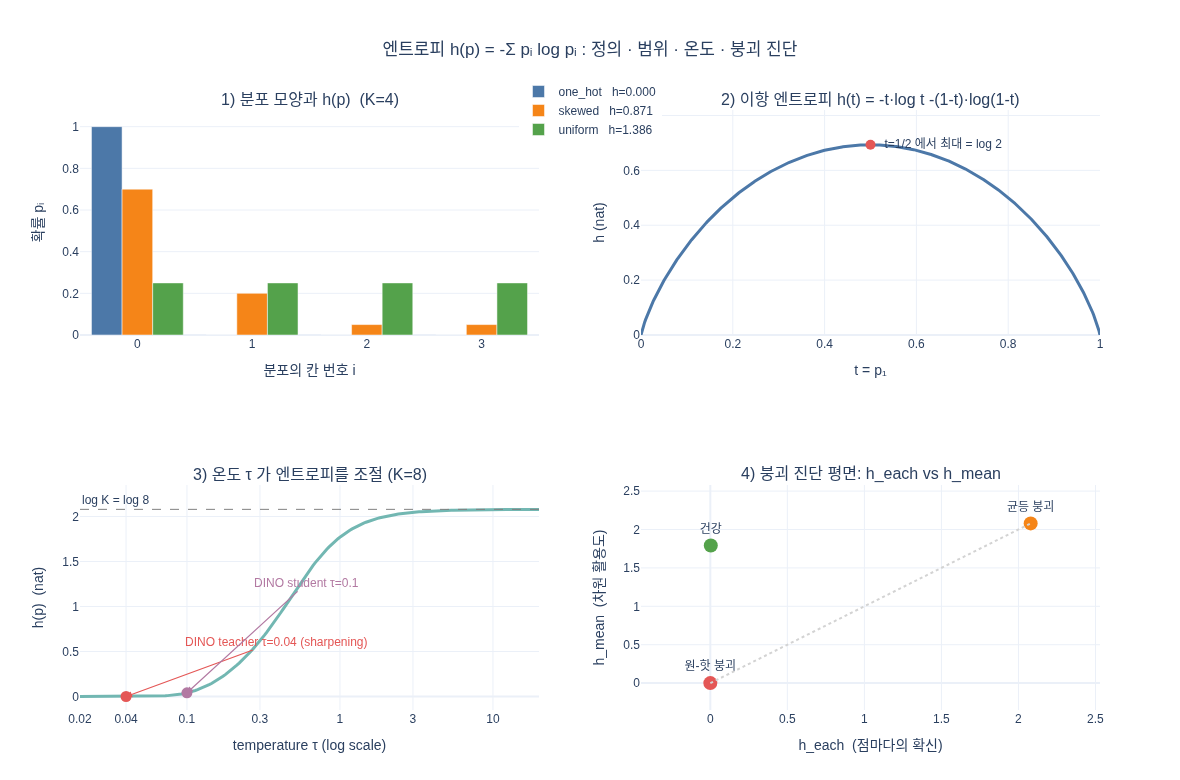

saved expy.png


In [10]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "1) 분포 모양과 h(p)  (K=4)",
        "2) 이항 엔트로피 h(t) = -t·log t -(1-t)·log(1-t)",
        "3) 온도 τ 가 엔트로피를 조절 (K=8)",
        "4) 붕괴 진단 평면: h_each vs h_mean",
    ),
)

# --- (1) 세 분포 막대 ---
K4 = 4
dists = [("one_hot", one_hot, "#4C78A8"), ("skewed", skewed, "#F58518"), ("uniform", uniform, "#54A24B")]
for name, d, color in dists:
    fig.add_trace(
        go.Bar(x=[str(i) for i in range(K4)], y=d, name=f"{name}   h={entropy(d):.3f}",
               marker_color=color, legendgroup="d"),
        row=1, col=1,
    )

# --- (2) 이항 엔트로피 ---
fig.add_trace(go.Scatter(x=t, y=h_binary, mode="lines", name="h(t)",
                         line=dict(color="#4C78A8", width=3), showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=[0.5], y=[np.log(2)], mode="markers+text", text=["  t=1/2 에서 최대 = log 2"],
                         textposition="middle right", marker=dict(size=10, color="#E45756"),
                         showlegend=False), row=1, col=2)

# --- (3) 온도 스윕 ---
taus = np.logspace(np.log10(0.02), np.log10(20), 200)
h_tau = np.array([entropy(softmax(logits, tt)) for tt in taus])
fig.add_trace(go.Scatter(x=taus, y=h_tau, mode="lines", line=dict(color="#72B7B2", width=3),
                         showlegend=False), row=2, col=1)
fig.add_hline(y=np.log(8), line=dict(dash="dash", color="gray", width=1),
              annotation_text="log K = log 8", annotation_position="top left", row=2, col=1)
marks = [(0.04, "DINO teacher τ=0.04 (sharpening)", "#E45756", 150, -55),
         (0.1, "DINO student τ=0.1", "#B279A2", 120, -110)]
for tt, lab, col, ax_, ay_ in marks:
    yy = entropy(softmax(logits, tt))
    fig.add_trace(go.Scatter(x=[tt], y=[yy], mode="markers",
                             marker=dict(size=11, color=col), showlegend=False), row=2, col=1)
    fig.add_annotation(x=np.log10(tt), y=yy, text=lab, showarrow=True, arrowhead=2,
                       arrowsize=1, arrowwidth=1.2, arrowcolor=col,
                       ax=ax_, ay=ay_, font=dict(size=12, color=col),
                       row=2, col=1)

# --- (4) 진단 평면 ---
logK = np.log(8)
pts = [("건강", 0.003, 1.791, "#54A24B"), ("원-핫 붕괴", 0.0, 0.0, "#E45756"), ("균등 붕괴", logK, logK, "#F58518")]
for name, he, hm, col in pts:
    fig.add_trace(go.Scatter(x=[he], y=[hm], mode="markers+text", text=[name], textposition="top center",
                             marker=dict(size=14, color=col), showlegend=False), row=2, col=2)
fig.add_trace(go.Scatter(x=[0, logK], y=[0, logK], mode="lines",
                         line=dict(dash="dot", color="lightgray"), showlegend=False), row=2, col=2)

fig.update_xaxes(title_text="분포의 칸 번호 i", row=1, col=1)
fig.update_yaxes(title_text="확률 pᵢ", range=[0, 1.08], row=1, col=1)
fig.update_xaxes(title_text="t = p₁", row=1, col=2)
fig.update_yaxes(title_text="h (nat)", range=[0, 0.82], row=1, col=2)
fig.update_xaxes(title_text="temperature τ (log scale)", type="log",
                 tickvals=[0.02, 0.04, 0.1, 0.3, 1, 3, 10],
                 ticktext=["0.02", "0.04", "0.1", "0.3", "1", "3", "10"], row=2, col=1)
fig.update_yaxes(title_text="h(p)  (nat)", range=[-0.15, 2.35], row=2, col=1)
fig.update_xaxes(title_text="h_each  (점마다의 확신)", range=[-0.45, logK + 0.45], row=2, col=2)
fig.update_yaxes(title_text="h_mean  (차원 활용도)", range=[-0.35, logK + 0.5], row=2, col=2)

fig.update_layout(height=780, width=1180, barmode="group",
                  title_text="엔트로피 h(p) = -Σ pᵢ log pᵢ : 정의 · 범위 · 온도 · 붕괴 진단",
                  title_x=0.5,
                  margin=dict(t=110, b=70),
                  legend=dict(orientation="h", y=1.055, x=0.5, xanchor="center",
                              font=dict(size=12)),
                  template="plotly_white")

_show(fig)

fig.write_image("expy.png", scale=2)
print("saved expy.png")

## 7. 정리

| 항목 | 내용 |
|---|---|
| 정의 | $h(p) = -\sum_i p_i \log p_i$ |
| 정체 | 놀람 $-\log p_i$ 의 기댓값 |
| 범위 | $0 \le h(p) \le \log K$ |
| 최소 | 원-핫 분포 → $h = 0$ |
| 최대 | 균등분포 → $h = \log K$ |
| 규약 | $0\log 0 = 0$ (극한값), 코드에서는 clamp |
| 조절 | softmax 온도 $\tau$: 작을수록 뾰족 → $h \downarrow$ |
| DINO | $H(q,p) = h(q) + D_{KL}(q\|p)$ 의 첫 항, 붕괴 진단 지표 `h_each`/`h_mean` |